### Import the Libraries

In [1]:
# Diabetes Prediction Using Machine Learning

## Project Overview

# This project develops and evaluates multiple machine learning models for diabetes prediction using health-related 
# indicators. The workflow includes data exploration, preprocessing, model development, hyperparameter optimization,
# and explainable AI using SHAP to identify the most influential predictors.

In [2]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Phase:1 Load and understand the Dataset

In [3]:
df = pd.read_csv(r"D:data/diabetes_binary_health_indicators_BRFSS2015.csv")
print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

Dataset loaded: 253,680 rows, 22 columns


### Data Understanding

#### We start by loading the CDC Diabetes Health Indicators dataset (BRFSS 2015) and checking its structure, size, and data types before doing any analysis.

In [4]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset shape: 253,680 rows × 22 columns


In [6]:
df.columns.tolist()

['Diabetes_binary',
 'HighBP',
 'HighChol',
 'CholCheck',
 'BMI',
 'Smoker',
 'Stroke',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'Fruits',
 'Veggies',
 'HvyAlcoholConsump',
 'AnyHealthcare',
 'NoDocbcCost',
 'GenHlth',
 'MentHlth',
 'PhysHlth',
 'DiffWalk',
 'Sex',
 'Age',
 'Education',
 'Income']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


In [9]:
missing_values = df.isnull().sum()
print(f"Total missing values: {missing_values.sum()}")
missing_values[missing_values > 0]

Total missing values: 0


Series([], dtype: int64)

In [11]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,} ({duplicate_count/len(df):.2%} of data)")

## we can not remove duplicates as the parameters can be the same for two persons, so we keep them

Duplicate rows: 24,206 (9.54% of data)


In [12]:
counts = df["Diabetes_binary"].value_counts()
pct = df["Diabetes_binary"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"Count": counts, "Percentage": pct.round(2)})
summary.index = summary.index.map({0: "No Diabetes", 1: "Diabetes/Prediabetes"})
summary

,Count,Percentage
Diabetes_binary,,
No Diabetes,218334,86.07
Diabetes/Prediabetes,35346,13.93


### Target Variable Analysis

In [13]:
df["Diabetes_binary"].value_counts()

Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

In [14]:
(df["Diabetes_binary"].value_counts(normalize=True) * 100).round(2)

Diabetes_binary
0.0    86.07
1.0    13.93
Name: proportion, dtype: float64

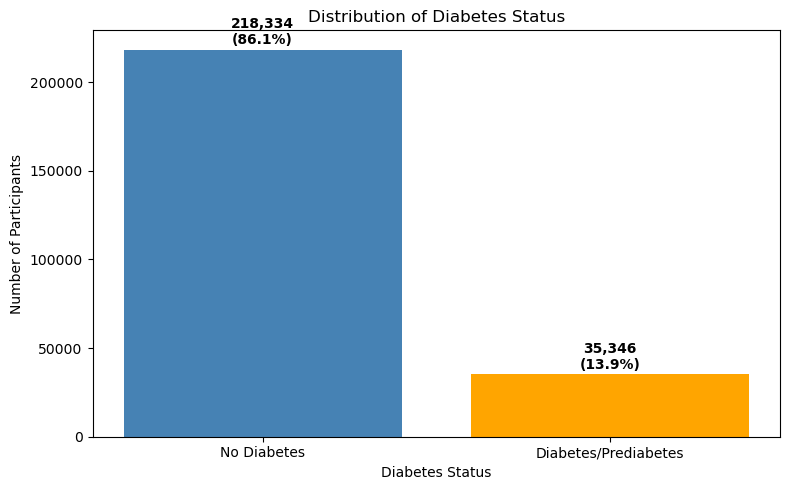

In [15]:
target_counts = df["Diabetes_binary"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(
    ["No Diabetes", "Diabetes/Prediabetes"],
    target_counts.values,
    color=["steelblue", "orange"]
)

for bar, val in zip(bars, target_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 3000,
              f"{val:,}\n({val/len(df):.1%})", ha="center", fontweight="bold")

plt.xlabel("Diabetes Status")
plt.ylabel("Number of Participants")
plt.title("Distribution of Diabetes Status")
plt.tight_layout()
plt.show()

# Phase 2: Exploratory Data Analysis (EDA)

In [16]:
# Features grouped by data type for targeted EDA:
# binary (yes/no flags), ordinal (ranked categories), continuous (counts/measurements)

binary_features = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits',
    'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
    'NoDocbcCost', 'DiffWalk', 'Sex'
]

ordinal_features = [
    'Age', 'Education', 'Income', 'GenHlth'
]

continuous_features = [
    'BMI', 'MentHlth', 'PhysHlth'
]

target = "Diabetes_binary"

#### Binary_features Analysis

In [17]:
binary_summary = []
for feature in binary_features:
    prevalence = (
        df.groupby(feature)["Diabetes_binary"]
        .mean()
        .mul(100)
    )
    binary_summary.append({
        "Feature": feature,
        "No (%)": round(prevalence.get(0, 0), 2),
        "Yes (%)": round(prevalence.get(1, 0), 2),
        "Difference (%)": round(prevalence.get(1, 0) - prevalence.get(0, 0), 2)
    })
binary_summary = (
    pd.DataFrame(binary_summary)
    .sort_values("Difference (%)", ascending=False)
)
binary_summary

,Feature,No (%),Yes (%),Difference (%)
5,HeartDiseaseorAttack,11.95,32.97,21.02
12,DiffWalk,10.53,30.75,20.21
4,Stroke,13.18,31.75,18.57
0,HighBP,6.04,24.45,18.41
1,HighChol,7.98,22.01,14.03
2,CholCheck,2.54,14.37,11.83
3,Smoker,12.06,16.29,4.24
11,NoDocbcCost,13.60,17.52,3.92
10,AnyHealthcare,11.45,14.06,2.61
13,Sex,12.97,15.16,2.19


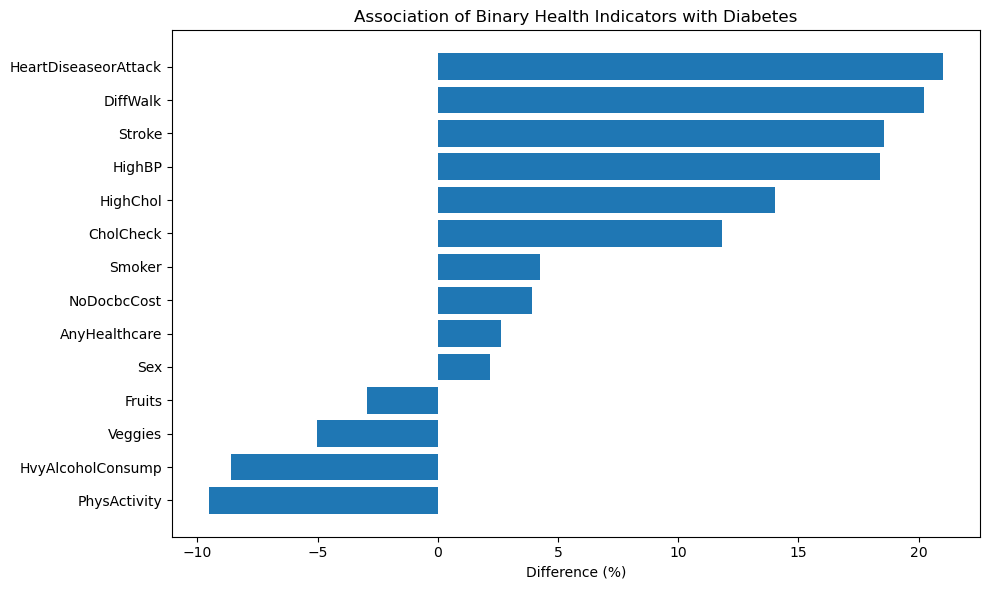

In [18]:
plt.figure(figsize=(10, 6))
plt.barh(binary_summary["Feature"], binary_summary["Difference (%)"])
plt.gca().invert_yaxis()   # <-- fixes the ordering
plt.xlabel("Difference (%)")
plt.title("Association of Binary Health Indicators with Diabetes")
plt.tight_layout()
plt.show()

#### Ordinal_features Analysis

In [19]:
age_labels = {
    1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39", 5: "40-44",
    6: "45-49", 7: "50-54", 8: "55-59", 9: "60-64", 10: "65-69",
    11: "70-74", 12: "75-79", 13: "80+"
}
age_table = (
    df.groupby("Age")["Diabetes_binary"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
)
age_table["Age"] = age_table["Age"].map(age_labels)
age_table.rename(columns={
    "Age": "Age Group",
    "Diabetes_binary": "Diabetes Prevalence (%)"
}, inplace=True)
age_table

,Age Group,Diabetes Prevalence (%)
0,18-24,1.37
1,25-29,1.84
2,30-34,2.82
3,35-39,4.53
4,40-44,6.50
5,45-49,8.79
6,50-54,11.74
7,55-59,13.83
8,60-64,17.25
9,65-69,20.37


In [20]:
genhlth_labels = {
    1: "Excellent", 2: "Very Good", 3: "Good", 4: "Fair", 5: "Poor"
}
genhlth_table = (
    df.groupby("GenHlth")["Diabetes_binary"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
)
genhlth_table["GenHlth"] = genhlth_table["GenHlth"].map(genhlth_labels)
genhlth_table.rename(columns={
    "GenHlth": "General Health",
    "Diabetes_binary": "Diabetes Prevalence (%)"
}, inplace=True)
genhlth_table

,General Health,Diabetes Prevalence (%)
0,Excellent,2.52
1,Very Good,7.16
2,Good,17.79
3,Fair,31.01
4,Poor,37.89


In [21]:
education_labels = {
    1: "Never attended school",
    2: "Elementary (Grades 1-8)",
    3: "Some High School",
    4: "High School Graduate",
    5: "Some College/Technical School",
    6: "College Graduate"
}
education_table = (
    df.groupby("Education")["Diabetes_binary"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
)
education_table["Education"] = education_table["Education"].map(education_labels)
education_table.rename(columns={
    "Education": "Education Level",
    "Diabetes_binary": "Diabetes Prevalence (%)"
}, inplace=True)
education_table

,Education Level,Diabetes Prevalence (%)
0,Never attended school,27.01
1,Elementary (Grades 1-8),29.26
2,Some High School,24.22
3,High School Graduate,17.64
4,Some College/Technical School,14.81
5,College Graduate,9.69


In [22]:
income_labels = {
    1: "< $10,000",
    2: "$10,000-$14,999",
    3: "$15,000-$19,999",
    4: "$20,000-$24,999",
    5: "$25,000-$34,999",
    6: "$35,000-$49,999",
    7: "$50,000-$74,999",
    8: "$75,000+"
}

income_table = (
    df.groupby("Income")["Diabetes_binary"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
)

income_table["Income"] = income_table["Income"].map(income_labels)
income_table.rename(columns={
    "Income": "Income Level",
    "Diabetes_binary": "Diabetes Prevalence (%)"
}, inplace=True)

income_table

,Income Level,Diabetes Prevalence (%)
0,"< $10,000",24.29
1,"$10,000-$14,999",26.19
2,"$15,000-$19,999",22.31
3,"$20,000-$24,999",20.13
4,"$25,000-$34,999",17.40
5,"$35,000-$49,999",14.51
6,"$50,000-$74,999",12.18
7,"$75,000+",7.96


C:\Users\khan\AppData\Local\Temp\ipykernel_354844\3540650100.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(education_table["Education Level"], rotation=45, ha='right')
C:\Users\khan\AppData\Local\Temp\ipykernel_354844\3540650100.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(income_table["Income Level"], rotation=45, ha='right')


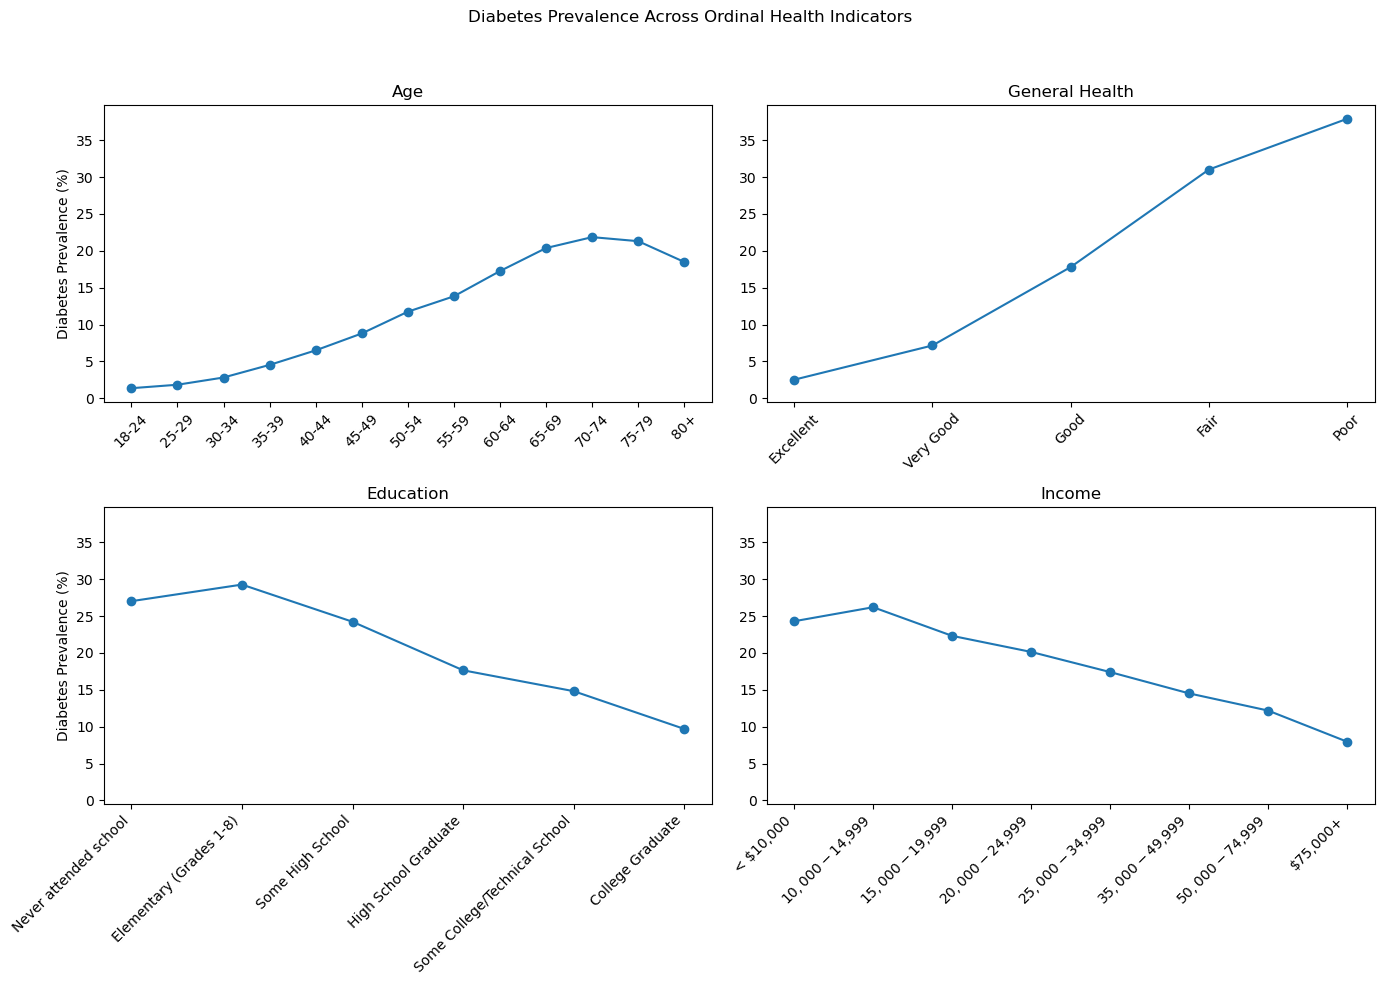

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

axes[0, 0].plot(age_table["Age Group"], age_table["Diabetes Prevalence (%)"], marker="o")
axes[0, 0].set_title("Age")
axes[0, 0].set_ylabel("Diabetes Prevalence (%)")
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].plot(genhlth_table["General Health"], genhlth_table["Diabetes Prevalence (%)"], marker="o")
axes[0, 1].set_title("General Health")
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].plot(education_table["Education Level"], education_table["Diabetes Prevalence (%)"], marker="o")
axes[1, 0].set_title("Education")
axes[1, 0].set_ylabel("Diabetes Prevalence (%)")
axes[1, 0].set_xticklabels(education_table["Education Level"], rotation=45, ha='right')

axes[1, 1].plot(income_table["Income Level"], income_table["Diabetes Prevalence (%)"], marker="o")
axes[1, 1].set_title("Income")
axes[1, 1].set_xticklabels(income_table["Income Level"], rotation=45, ha='right')

# Force y-axis tick labels on every subplot, not just the left column
for ax in axes.flat:
    ax.tick_params(axis='y', labelleft=True)

plt.suptitle("Diabetes Prevalence Across Ordinal Health Indicators")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Continous_features Analysis

In [24]:
continuous_summary = (
    df[continuous_features]
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .T
    .round(2)
)
continuous_summary.columns = [
    "Mean", "Median", "Standard Deviation", "Minimum", "Maximum"
]
continuous_summary

,Mean,Median,Standard Deviation,Minimum,Maximum
BMI,28.38,27.0,6.61,12.0,98.0
MentHlth,3.18,0.0,7.41,0.0,30.0
PhysHlth,4.24,0.0,8.72,0.0,30.0


C:\Users\khan\AppData\Local\Temp\ipykernel_354844\215425427.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Diabetes", "Diabetes"])
C:\Users\khan\AppData\Local\Temp\ipykernel_354844\215425427.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Diabetes", "Diabetes"])
C:\Users\khan\AppData\Local\Temp\ipykernel_354844\215425427.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Diabetes", "Diabetes"])


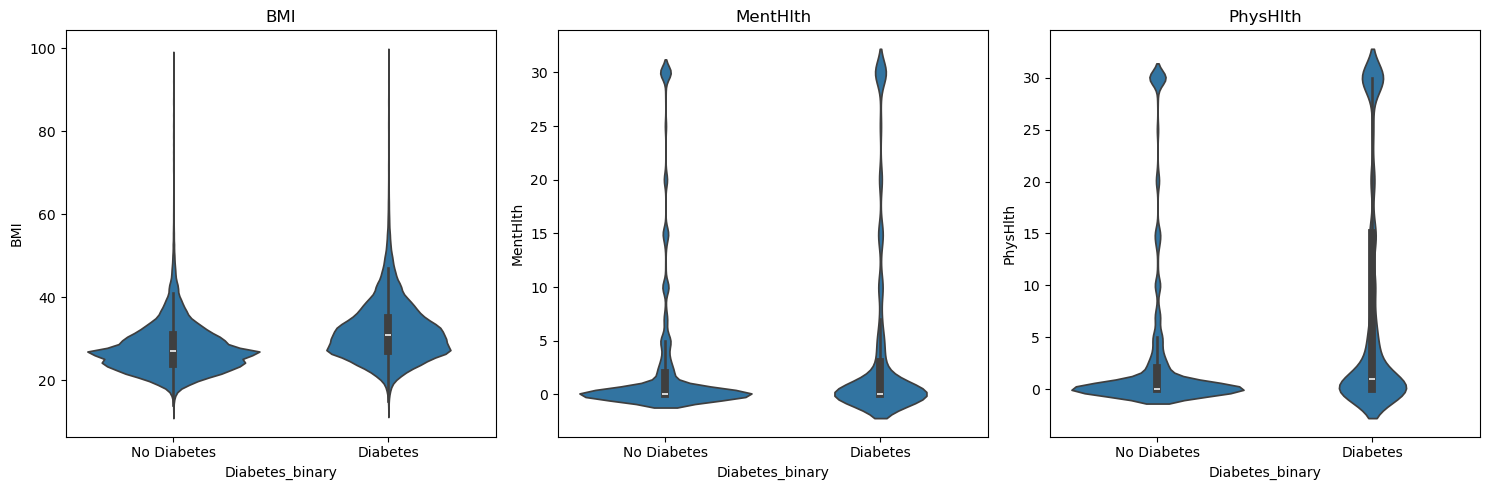

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feature in zip(axes, continuous_features):
    sns.violinplot(data=df, x="Diabetes_binary", y=feature, ax=ax)
    ax.set_title(feature)
    ax.set_xticklabels(["No Diabetes", "Diabetes"])

plt.tight_layout()
plt.show()

# Phase 3: Data Preprocessing

In [27]:
X = df.drop(columns="Diabetes_binary")
y = df["Diabetes_binary"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (253680, 21)
Target shape: (253680,)


In [28]:
## Train Test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (202944, 21)
Testing set : (50736, 21)

Training target distribution:
Diabetes_binary
0.0    0.860666
1.0    0.139334
Name: proportion, dtype: float64

Testing target distribution:
Diabetes_binary
0.0    0.860671
1.0    0.139329
Name: proportion, dtype: float64


In [29]:
## check class imbalance 

class_distribution = (
    y_train.value_counts()
    .rename(index={0.0: "No Diabetes", 1.0: "Diabetes"})
    .to_frame(name="Count")
)

class_distribution["Percentage (%)"] = (
    class_distribution["Count"] / class_distribution["Count"].sum() * 100
).round(2)

class_distribution

,Count,Percentage (%)
Diabetes_binary,,
No Diabetes,174667,86.07
Diabetes,28277,13.93


# Phase 4: Machine learning Models

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from xgboost import XGBClassifier
import shap

### Model 1: Logistic regression

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
log_reg = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [33]:
## Generate predictions

# Predicted class labels
y_pred_log = log_reg.predict(X_test_scaled)

# Predicted probabilities (for ROC-AUC)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

In [34]:
## Evaluate the model

log_reg_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log),
    "Recall": recall_score(y_test, y_pred_log),
    "F1-Score": f1_score(y_test, y_pred_log),
    "ROC-AUC": roc_auc_score(y_test, y_prob_log)
}

pd.DataFrame([log_reg_results]).round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7315,0.3107,0.7611,0.4413,0.8196


In [69]:

print("Classification Report:\n")
print(classification_report(y_test, y_pred_log, target_names=["No Diabetes", "Diabetes/Prediabetes"]))

cm = confusion_matrix(y_test, y_pred_log)
print("\nConfusion Matrix:")
print(f"True Negatives:  {cm[0,0]:,}   False Positives: {cm[0,1]:,}")
print(f"False Negatives: {cm[1,0]:,}   True Positives:  {cm[1,1]:,}")

Classification Report:

                      precision    recall  f1-score   support

         No Diabetes       0.95      0.73      0.82     43667
Diabetes/Prediabetes       0.31      0.76      0.44      7069

            accuracy                           0.73     50736
           macro avg       0.63      0.74      0.63     50736
        weighted avg       0.86      0.73      0.77     50736


Confusion Matrix:
True Negatives:  31,734   False Positives: 11,933
False Negatives: 1,689   True Positives:  5,380


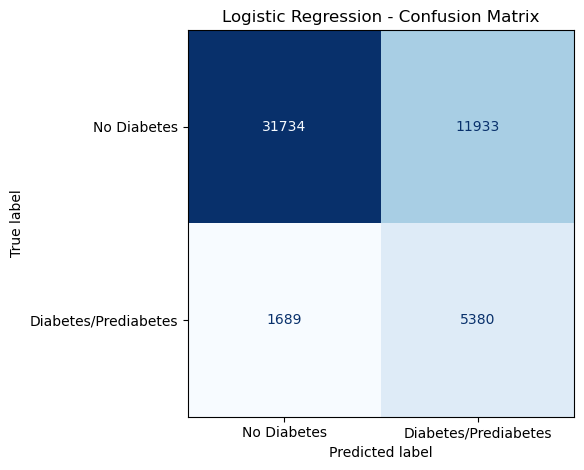

In [36]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    cmap="Blues",
    colorbar=False,
    display_labels=["No Diabetes", "Diabetes/Prediabetes"]
)
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

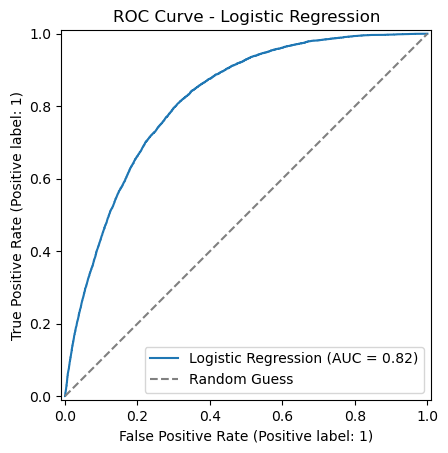

In [37]:
## ROC Curve

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_log,
    name="Logistic Regression"
)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

### Model 2: Decision Tree

In [38]:
decision_tree = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42
)
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=8,
                       min_samples_leaf=50, random_state=42)

In [39]:
## Make Predictions
y_pred_dt = decision_tree.predict(X_test)
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

In [40]:
### Evaluate

dt_results = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1-Score": f1_score(y_test, y_pred_dt),
    "ROC-AUC": roc_auc_score(y_test, y_prob_dt)
}
pd.DataFrame([dt_results]).round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.7072,0.2934,0.7826,0.4268,0.8132


In [45]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_dt, target_names=["No Diabetes", "Diabetes/Prediabetes"]))

cm = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix:")
print(f"True Negatives:  {cm[0,0]:,}   False Positives: {cm[0,1]:,}")
print(f"False Negatives: {cm[1,0]:,}   True Positives:  {cm[1,1]:,}")

Classification Report:

                      precision    recall  f1-score   support

         No Diabetes       0.95      0.69      0.80     43667
Diabetes/Prediabetes       0.29      0.78      0.43      7069

            accuracy                           0.71     50736
           macro avg       0.62      0.74      0.62     50736
        weighted avg       0.86      0.71      0.75     50736


Confusion Matrix:
True Negatives:  30,346   False Positives: 13,321
False Negatives: 1,537   True Positives:  5,532


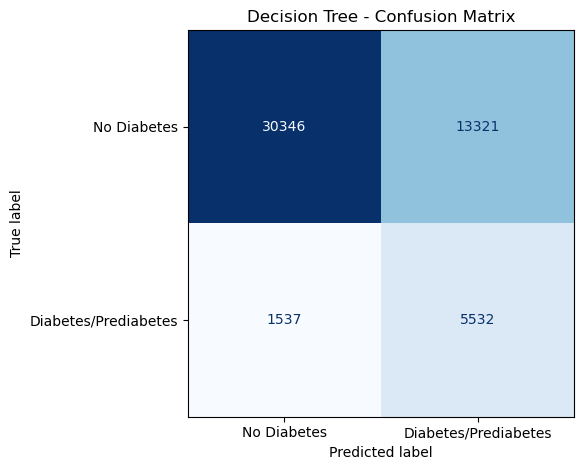

In [48]:
## Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    cmap="Blues",
    colorbar=False,
    display_labels=["No Diabetes", "Diabetes/Prediabetes"],
    values_format="d"
)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

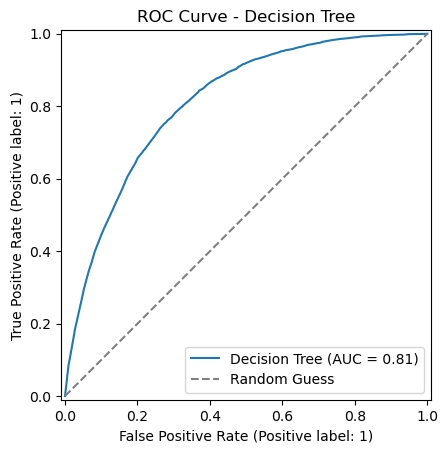

In [58]:
## ROC Curve


RocCurveDisplay.from_predictions(
    y_test,
    y_prob_dt,
    name="Decision Tree"
)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

### Model 3: Random Forest

In [50]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
random_forest.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=20, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [53]:
## Make predictions

y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [54]:
## Evaluate the model 

rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
}
pd.DataFrame([rf_results]).round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.742,0.3197,0.755,0.4492,0.8246


In [55]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=["No Diabetes", "Diabetes/Prediabetes"]))

cm = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(f"True Negatives:  {cm[0,0]:,}   False Positives: {cm[0,1]:,}")
print(f"False Negatives: {cm[1,0]:,}   True Positives:  {cm[1,1]:,}")

Classification Report:

                      precision    recall  f1-score   support

         No Diabetes       0.95      0.74      0.83     43667
Diabetes/Prediabetes       0.32      0.75      0.45      7069

            accuracy                           0.74     50736
           macro avg       0.63      0.75      0.64     50736
        weighted avg       0.86      0.74      0.78     50736


Confusion Matrix:
True Negatives:  32,309   False Positives: 11,358
False Negatives: 1,732   True Positives:  5,337


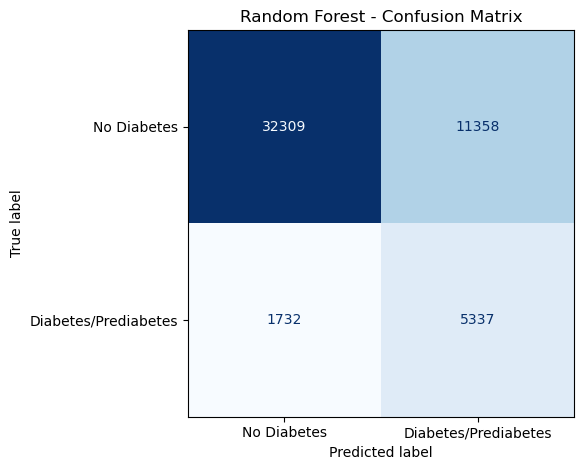

In [56]:
## Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues",
    colorbar=False,
    display_labels=["No Diabetes", "Diabetes/Prediabetes"],
    values_format="d"
)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

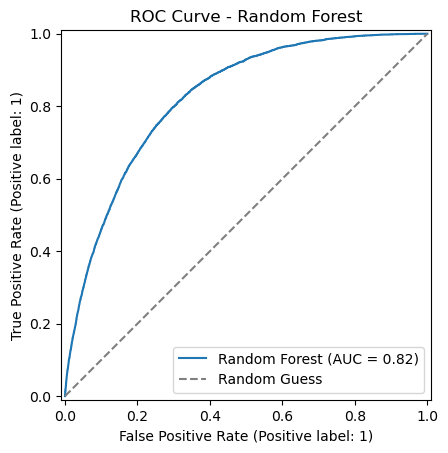

In [57]:
## ROC Curve

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

### Model 4: XGBoost

In [59]:
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 6.18


In [61]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [63]:
## Make prediction 

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [65]:
## Evaluate model 

xgb_results = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1-Score": f1_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb)
}
pd.DataFrame([xgb_results]).round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.7271,0.3106,0.7857,0.4452,0.8262


In [66]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb, target_names=["No Diabetes", "Diabetes/Prediabetes"]))

cm = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:")
print(f"True Negatives:  {cm[0,0]:,}   False Positives: {cm[0,1]:,}")
print(f"False Negatives: {cm[1,0]:,}   True Positives:  {cm[1,1]:,}")

Classification Report:

                      precision    recall  f1-score   support

         No Diabetes       0.95      0.72      0.82     43667
Diabetes/Prediabetes       0.31      0.79      0.45      7069

            accuracy                           0.73     50736
           macro avg       0.63      0.75      0.63     50736
        weighted avg       0.86      0.73      0.77     50736


Confusion Matrix:
True Negatives:  31,338   False Positives: 12,329
False Negatives: 1,515   True Positives:  5,554


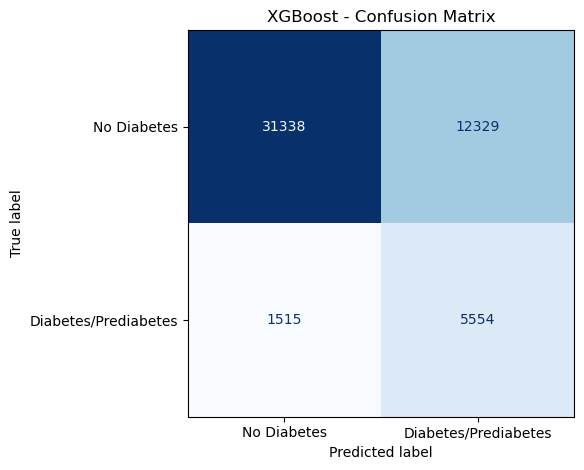

In [67]:
## Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap="Blues",
    colorbar=False,
    display_labels=["No Diabetes", "Diabetes/Prediabetes"],
    values_format="d"
)
plt.title("XGBoost - Confusion Matrix")
plt.tight_layout()
plt.show()

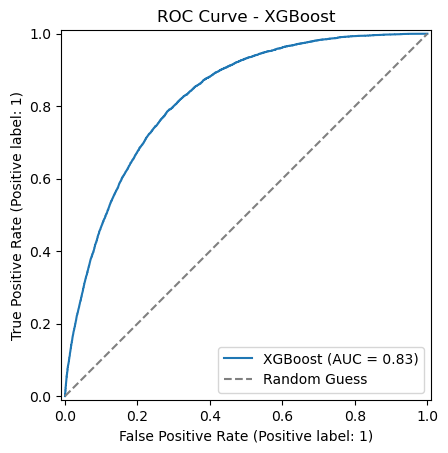

In [68]:
## ROC Curve

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

In [71]:
## Baseline model comparison (before hyperparameter tuning

print("Baseline model comparison (before hyperparameter tuning):")
pd.DataFrame([log_reg_results, dt_results, rf_results, xgb_results]).round(4)

Baseline model comparison (before hyperparameter tuning):


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7315,0.3107,0.7611,0.4413,0.8196
1,Decision Tree,0.7072,0.2934,0.7826,0.4268,0.8132
2,Random Forest,0.7420,0.3197,0.7550,0.4492,0.8246
3,XGBoost,0.7271,0.3106,0.7857,0.4452,0.8262


# Phase 5: Hyperparameter Optimization

In [72]:
## Define Hyperparameter Search Space

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5]
}

In [73]:
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs= -1
)
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=0.8, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constr...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=200, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 9],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [76]:
## View the Best Hyperparameters

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validated ROC-AUC (on training folds):")
print(round(random_search.best_score_, 4))

Best Parameters:
{'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.9}

Best Cross-Validated ROC-AUC (on training folds):
0.8312


### Final Optimized XGBoost Model

In [77]:
## Train the Optimized XGBoost Model

best_xgb = XGBClassifier(
    **random_search.best_params_,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)
best_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [78]:
## Generate Predictions

y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

In [79]:
## Evaluate the Optimized Model


best_xgb_results = {
    "Model": "Optimized XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best),
    "Recall": recall_score(y_test, y_pred_best),
    "F1-Score": f1_score(y_test, y_pred_best),
    "ROC-AUC": roc_auc_score(y_test, y_prob_best)
}
pd.DataFrame([best_xgb_results]).round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Optimized XGBoost,0.7205,0.3061,0.7945,0.442,0.8273


In [80]:
## Classification Report and Confusion Matrix

print("Classification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=["No Diabetes", "Diabetes/Prediabetes"]))

cm = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix:")
print(f"True Negatives:  {cm[0,0]:,}   False Positives: {cm[0,1]:,}")
print(f"False Negatives: {cm[1,0]:,}   True Positives:  {cm[1,1]:,}")

Classification Report:

                      precision    recall  f1-score   support

         No Diabetes       0.96      0.71      0.81     43667
Diabetes/Prediabetes       0.31      0.79      0.44      7069

            accuracy                           0.72     50736
           macro avg       0.63      0.75      0.63     50736
        weighted avg       0.86      0.72      0.76     50736


Confusion Matrix:
True Negatives:  30,938   False Positives: 12,729
False Negatives: 1,453   True Positives:  5,616


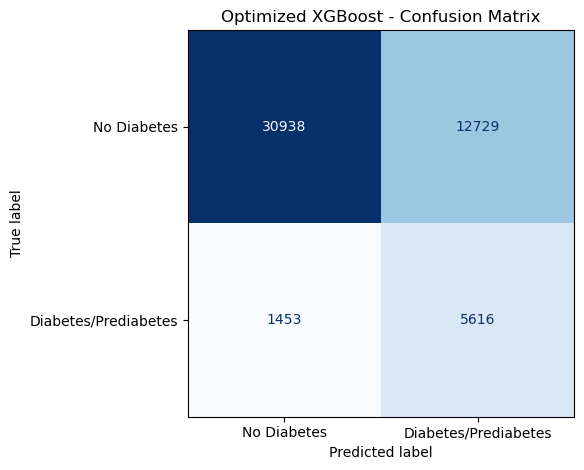

In [81]:
## Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    cmap="Blues",
    colorbar=False,
    display_labels=["No Diabetes", "Diabetes/Prediabetes"],
    values_format="d"
)
plt.title("Optimized XGBoost - Confusion Matrix")
plt.tight_layout()
plt.show()

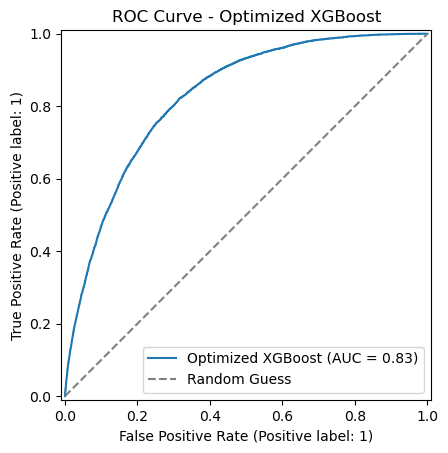

In [82]:
## ROC Curve

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_best,
    name="Optimized XGBoost"
)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curve - Optimized XGBoost")
plt.legend()
plt.show()

# Phase 6: Model Explainability

In [83]:
## Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,HighBP,0.540948
13,GenHlth,0.108929
1,HighChol,0.089088
16,DiffWalk,0.044432
6,HeartDiseaseorAttack,0.041930
18,Age,0.037787
3,BMI,0.034140
10,HvyAlcoholConsump,0.021427
2,CholCheck,0.018909
20,Income,0.014388


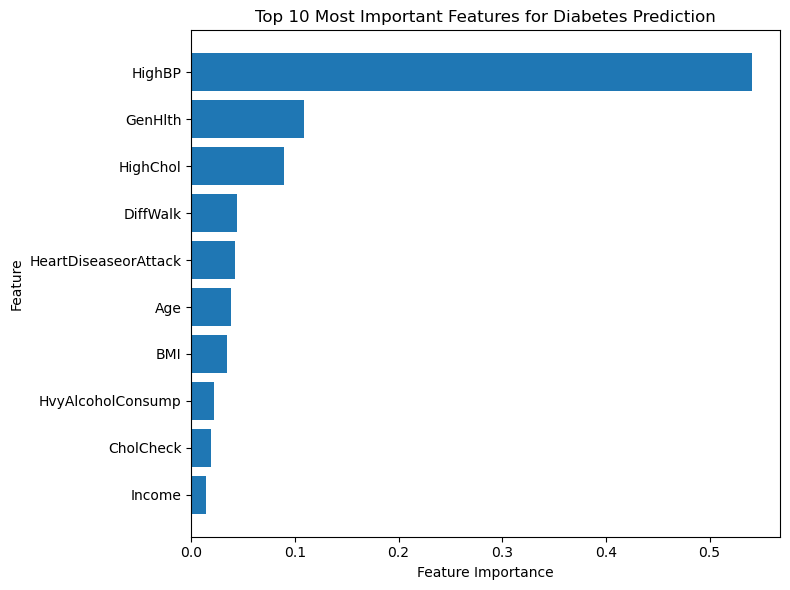

In [84]:
## Top 10 Most Important Features

top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features for Diabetes Prediction")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### SHAP explainability 

In [85]:
# Initialize JavaScript for Jupyter Notebook
shap.initjs()

## Create SHAP Explainer

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test)

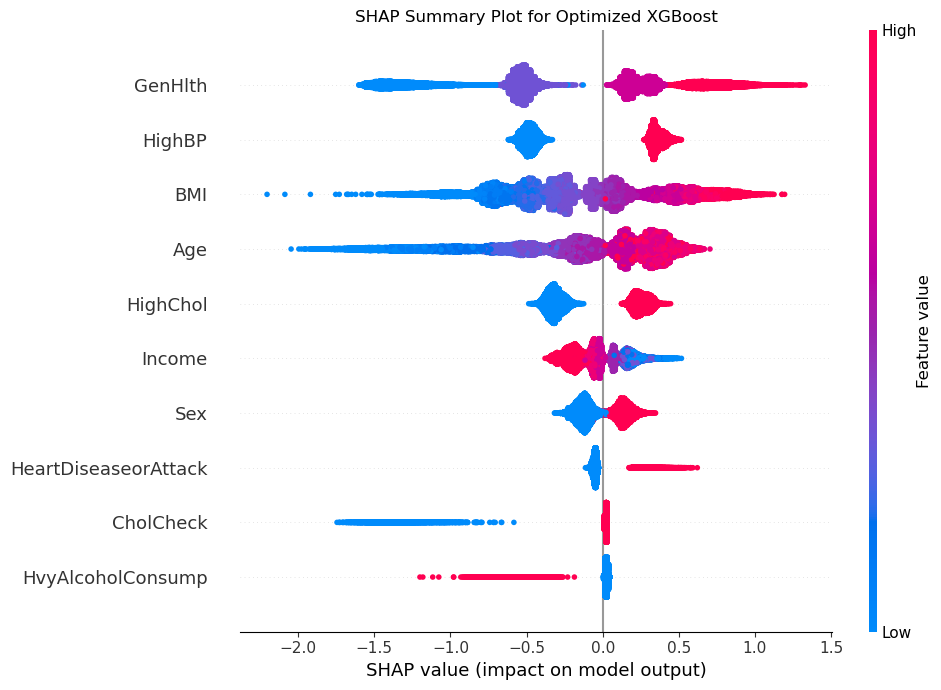

In [86]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
    max_display=10,
    plot_size=(10, 7),
    show=False
)
plt.title("SHAP Summary Plot for Optimized XGBoost")
plt.tight_layout()
plt.show()

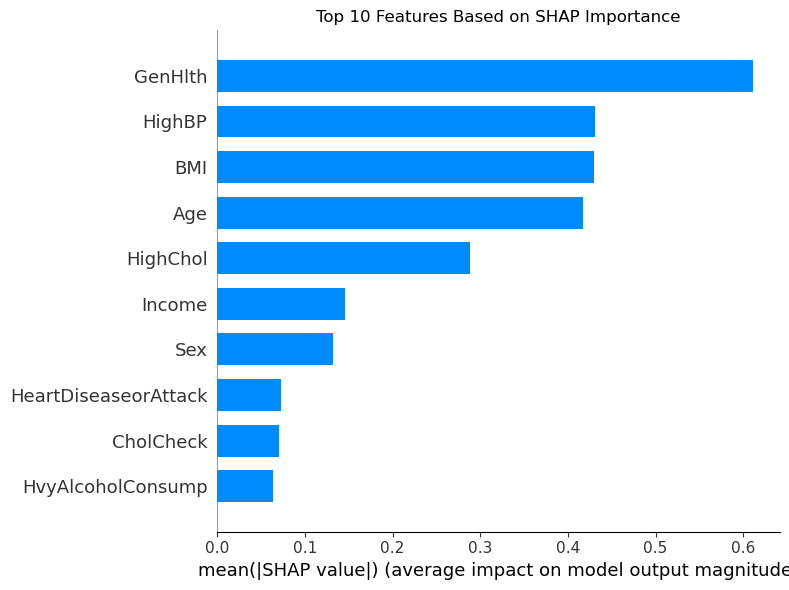

In [87]:
## SHAP Feature Importance (Bar Plot)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=10,
    plot_size=(8, 6),
    show=False
)
plt.title("Top 10 Features Based on SHAP Importance")
plt.tight_layout()
plt.show()

### Final Model Comparison

In [88]:
## Combine All Model Results

comparison_df = pd.DataFrame([
    log_reg_results,
    dt_results,
    rf_results,
    xgb_results,
    best_xgb_results
]).round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7315,0.3107,0.7611,0.4413,0.8196
1,Decision Tree,0.7072,0.2934,0.7826,0.4268,0.8132
2,Random Forest,0.7420,0.3197,0.7550,0.4492,0.8246
3,XGBoost,0.7271,0.3106,0.7857,0.4452,0.8262
4,Optimized XGBoost,0.7205,0.3061,0.7945,0.4420,0.8273


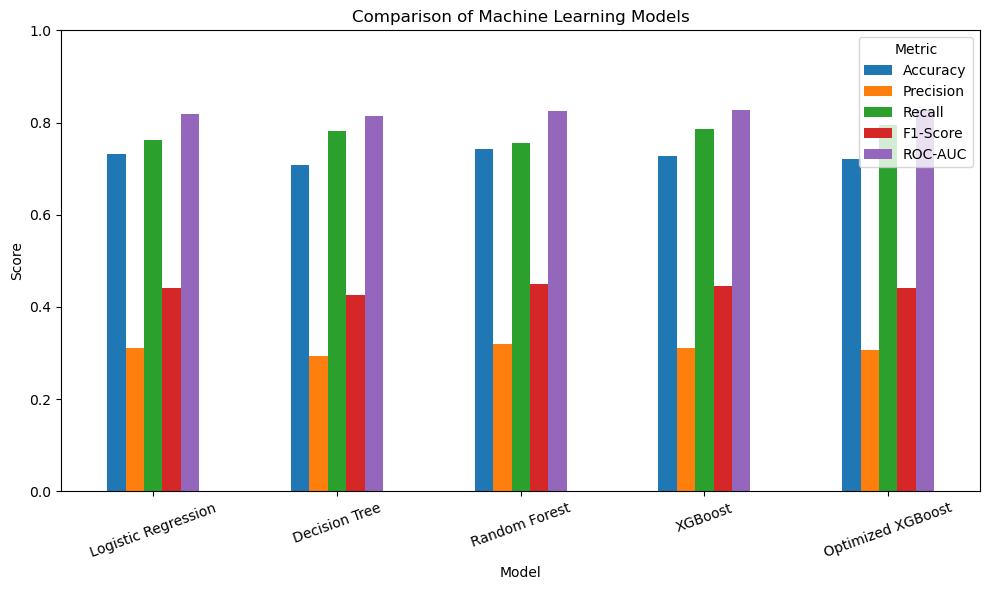

In [89]:
## Compare Evaluation Metrics Across Models

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

comparison_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.ylim(0,1)

plt.xticks(rotation=20)

plt.legend(title="Metric")

plt.tight_layout()

plt.show()

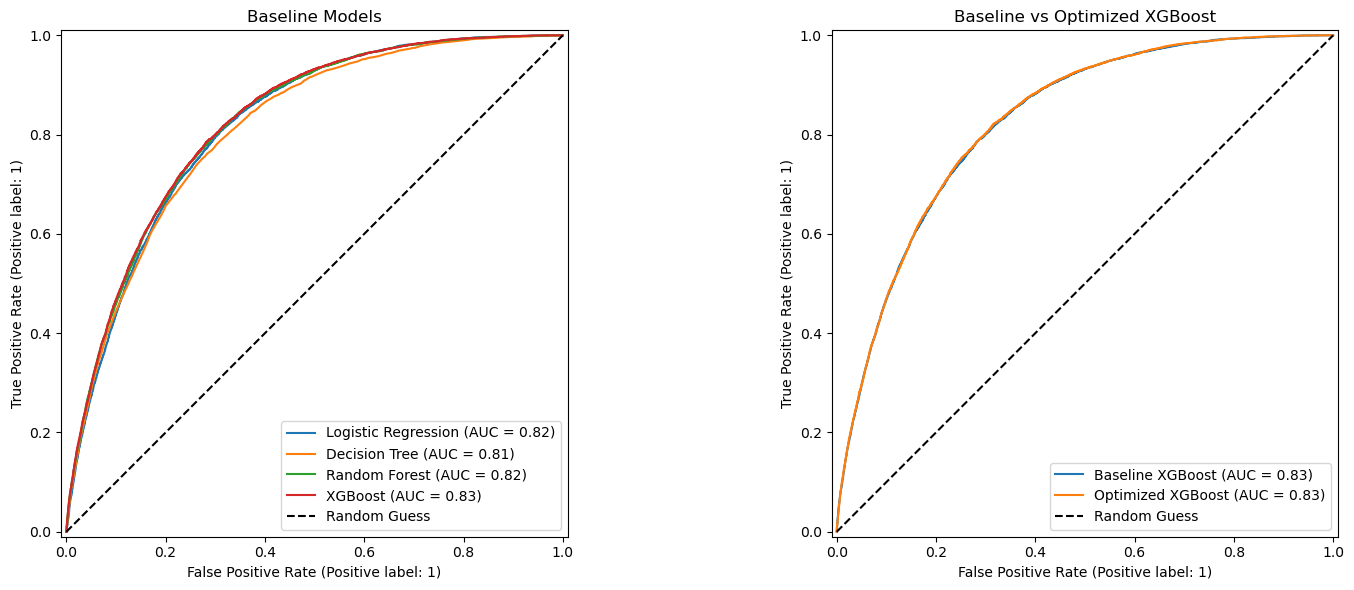

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

RocCurveDisplay.from_predictions(y_test, y_prob_log, name="Logistic Regression", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_prob_dt, name="Decision Tree", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name="XGBoost", ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", label="Random Guess")
axes[0].set_title("Baseline Models")
axes[0].legend()

RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name="Baseline XGBoost", ax=axes[1])
RocCurveDisplay.from_predictions(y_test, y_prob_best, name="Optimized XGBoost", ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", label="Random Guess")
axes[1].set_title("Baseline vs Optimized XGBoost")
axes[1].legend()

plt.tight_layout()
plt.show()